In [2]:
%pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


EXPERIMENT 5: BIVARIATE ANALYSIS
LINEAR AND LOGISTIC REGRESSION MODELING

1. DATASET SAMPLE
--------------------------------------------------

Pima Indians Diabetes Dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

UCI Diabetes Working Dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148  

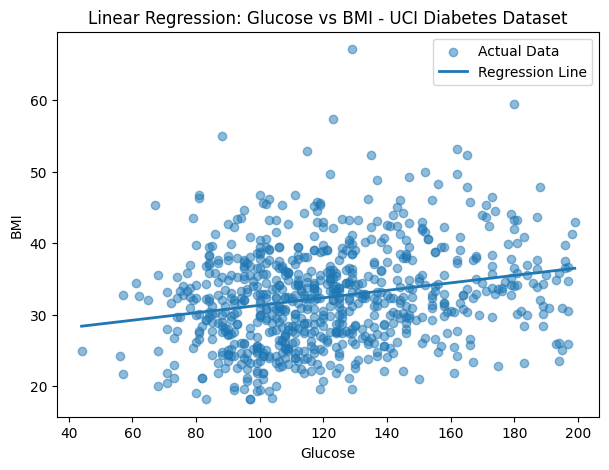


--------------------------------------------------
LINEAR REGRESSION: Pima Indians Diabetes Dataset
--------------------------------------------------
Independent Variable: Glucose
Dependent Variable: BMI
Slope: 0.0522
Intercept: 26.1063
R2 Score: 0.0534


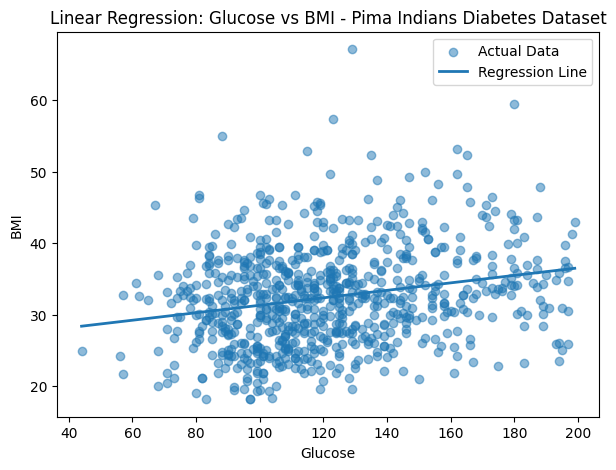


--------------------------------------------------
LOGISTIC REGRESSION: UCI Diabetes Dataset
--------------------------------------------------
Features: ['Glucose', 'BloodPressure', 'BMI', 'Age']
Target: Outcome
Training Samples: 614
Testing Samples: 154
Accuracy Score: 0.7078
Accuracy Percentage: 70.78 %

--------------------------------------------------
LOGISTIC REGRESSION: Pima Indians Diabetes Dataset
--------------------------------------------------
Features: ['Glucose', 'BloodPressure', 'BMI', 'Age']
Target: Outcome
Training Samples: 614
Testing Samples: 154
Accuracy Score: 0.7078
Accuracy Percentage: 70.78 %

MODEL COMPARISON
                      Dataset  Linear Regression R2  Logistic Regression Accuracy
         UCI Diabetes Dataset              0.053383                      0.707792
Pima Indians Diabetes Dataset              0.053383                      0.707792

BIVARIATE ANALYSIS


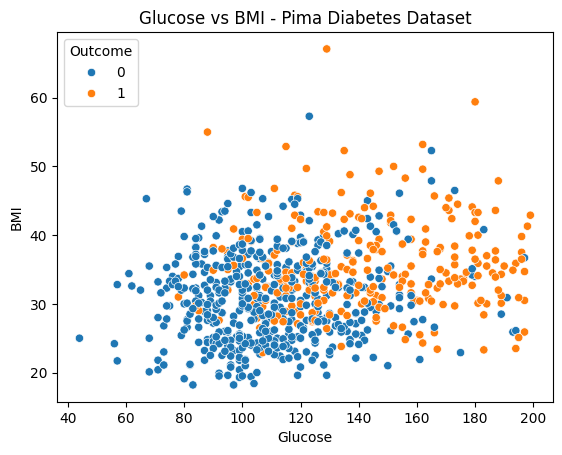


CORRELATION MATRIX
--------------------------------------------------
                Glucose  BloodPressure       BMI       Age   Outcome
Glucose        1.000000       0.218937  0.231049  0.266909  0.492782
BloodPressure  0.218937       1.000000  0.281257  0.324915  0.165723
BMI            0.231049       0.281257  1.000000  0.025597  0.312038
Age            0.266909       0.324915  0.025597  1.000000  0.238356
Outcome        0.492782       0.165723  0.312038  0.238356  1.000000

RESULT
Linear Regression was performed to study Glucose and BMI.
R2 score was calculated for Linear Regression.
Logistic Regression was used to predict diabetes Outcome.
Accuracy score was calculated for Logistic Regression.
Bivariate visualization was performed using a scatter plot.
Correlation analysis was also performed.
The experiment successfully demonstrated regression modeling.
EXPERIMENT 5 COMPLETED SUCCESSFULLY


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("EXPERIMENT 5: BIVARIATE ANALYSIS")
print("LINEAR AND LOGISTIC REGRESSION MODELING")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load Pima Indians Diabetes Dataset
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

pima_diabetes = pd.read_csv(url, names=columns)

# Create a working copy for the UCI analysis
uci_diabetes = pima_diabetes.copy()

print("\n1. DATASET SAMPLE")
print("-" * 50)

print("\nPima Indians Diabetes Dataset:")
print(pima_diabetes.head())

print("\nUCI Diabetes Working Dataset:")
print(uci_diabetes.head())

print("\nPima Dataset Shape:", pima_diabetes.shape)
print("UCI Dataset Shape:", uci_diabetes.shape)

# ------------------------------------------------------------
# 2. Handle invalid zero values
# ------------------------------------------------------------

medical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for data in [uci_diabetes, pima_diabetes]:
    for column in medical_columns:
        data[column] = data[column].replace(0, np.nan)
        data[column] = data[column].fillna(data[column].median())

print("\n2. MISSING/INVALID VALUES HANDLED")
print("-" * 50)

print(pima_diabetes.isnull().sum())

# ------------------------------------------------------------
# 3. Linear Regression
# Predict BMI using Glucose
# ------------------------------------------------------------

def linear_regression_analysis(data, dataset_name):

    X = data[["Glucose"]]
    Y = data["BMI"]

    model = LinearRegression()
    model.fit(X, Y)

    Y_pred = model.predict(X)

    r2 = r2_score(Y, Y_pred)

    print("\n" + "-" * 50)
    print("LINEAR REGRESSION:", dataset_name)
    print("-" * 50)

    print("Independent Variable: Glucose")
    print("Dependent Variable: BMI")
    print("Slope:", round(model.coef_[0], 4))
    print("Intercept:", round(model.intercept_, 4))
    print("R2 Score:", round(r2, 4))

    plt.figure(figsize=(7, 5))

    plt.scatter(
        X,
        Y,
        alpha=0.5,
        label="Actual Data"
    )

    sorted_indices = np.argsort(X["Glucose"].values)

    plt.plot(
        X["Glucose"].values[sorted_indices],
        Y_pred[sorted_indices],
        linewidth=2,
        label="Regression Line"
    )

    plt.xlabel("Glucose")
    plt.ylabel("BMI")
    plt.title("Linear Regression: Glucose vs BMI - " + dataset_name)
    plt.legend()
    plt.show()

    return r2


# Apply Linear Regression

uci_r2 = linear_regression_analysis(
    uci_diabetes,
    "UCI Diabetes Dataset"
)

pima_r2 = linear_regression_analysis(
    pima_diabetes,
    "Pima Indians Diabetes Dataset"
)

# ------------------------------------------------------------
# 4. Logistic Regression
# Predict Diabetes Outcome
# ------------------------------------------------------------

def logistic_regression_analysis(data, dataset_name):

    features = [
        "Glucose",
        "BloodPressure",
        "BMI",
        "Age"
    ]

    target = "Outcome"

    X = data[features]
    Y = data[target]

    X_train, X_test, Y_train, Y_test = train_test_split(
        X,
        Y,
        test_size=0.20,
        random_state=42,
        stratify=Y
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_scaled, Y_train)

    Y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(Y_test, Y_pred)

    print("\n" + "-" * 50)
    print("LOGISTIC REGRESSION:", dataset_name)
    print("-" * 50)

    print("Features:", features)
    print("Target:", target)
    print("Training Samples:", len(X_train))
    print("Testing Samples:", len(X_test))
    print("Accuracy Score:", round(accuracy, 4))
    print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

    return accuracy


# Apply Logistic Regression

uci_accuracy = logistic_regression_analysis(
    uci_diabetes,
    "UCI Diabetes Dataset"
)

pima_accuracy = logistic_regression_analysis(
    pima_diabetes,
    "Pima Indians Diabetes Dataset"
)

# ------------------------------------------------------------
# 5. Model Comparison
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

comparison = pd.DataFrame({
    "Dataset": [
        "UCI Diabetes Dataset",
        "Pima Indians Diabetes Dataset"
    ],
    "Linear Regression R2": [
        uci_r2,
        pima_r2
    ],
    "Logistic Regression Accuracy": [
        uci_accuracy,
        pima_accuracy
    ]
})

print(comparison.to_string(index=False))

# ------------------------------------------------------------
# 6. Bivariate Visualization
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BIVARIATE ANALYSIS")
print("=" * 70)

sns.scatterplot(
    data=pima_diabetes,
    x="Glucose",
    y="BMI",
    hue="Outcome"
)

plt.title("Glucose vs BMI - Pima Diabetes Dataset")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

# ------------------------------------------------------------
# 7. Correlation Analysis
# ------------------------------------------------------------

print("\nCORRELATION MATRIX")
print("-" * 50)

correlation = pima_diabetes[
    ["Glucose", "BloodPressure", "BMI", "Age", "Outcome"]
].corr()

print(correlation)

# ------------------------------------------------------------
# 8. Final Result
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RESULT")
print("=" * 70)

print("Linear Regression was performed to study Glucose and BMI.")
print("R2 score was calculated for Linear Regression.")
print("Logistic Regression was used to predict diabetes Outcome.")
print("Accuracy score was calculated for Logistic Regression.")
print("Bivariate visualization was performed using a scatter plot.")
print("Correlation analysis was also performed.")
print("The experiment successfully demonstrated regression modeling.")

print("=" * 70)
print("EXPERIMENT 5 COMPLETED SUCCESSFULLY")
print("=" * 70)

In [4]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
